# Predicting Serious or Fatal Road Collisions in Great Britain

**Task type:** supervised learning, binary classification.

**Question:** Using only information that is known about a road collision scene (road type, speed limit, junction, lighting, weather, road surface, time of day and similar), can we predict whether the collision was *serious or fatal* rather than *slight*?

**Dataset:** Department for Transport (DfT) *Road Safety Data, Collisions, 2025*, published as open data under the Open Government Licence. Source page: https://www.gov.uk/government/statistical-data-sets/road-safety-open-data (also listed on https://www.data.gov.uk). The file used here is `dft-road-casualty-statistics-collision-2025.csv`, stored in the same folder as this notebook.

**Notebook structure:** 1 Setup and Problem Definition, 2 Load and Inspect the Data, 3 Data Preparation and Preprocessing, 4 Model Selection and Training, 5 Model Evaluation, 6 Notebook Summary.

## 1. Setup and Problem Definition

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    PrecisionRecallDisplay, RocCurveDisplay,
    accuracy_score, average_precision_score, classification_report,
    confusion_matrix, f1_score, make_scorer, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_predict, cross_validate, train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
SEED = 42
DATA_PATH = "dft-road-casualty-statistics-collision-2025.csv"
os.makedirs("figures", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {"Slight": "#4C78A8", "Serious or fatal": "#E45756"}

**Target definition.** The DfT records collision severity as Fatal (1), Serious (2) or Slight (3). Fatal collisions are rare, so a three-class model would have very few examples of the class that matters most. I therefore combine Fatal and Serious into one positive class, called *serious or fatal*, and predict it against *slight*. This is the grouping used in road safety reporting, where fatal and serious injuries are usually considered together.

## 2. Load and Inspect the Data

In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
df.head()

Rows: 101,525   Columns: 44


,collision_index,collision_year,collision_ref_no,location_easting_osgr,location_northing_osgr,longitude,latitude,police_force,collision_severity,number_of_vehicles,...,carriageway_hazards_historic,carriageway_hazards,urban_or_rural_area,did_police_officer_attend_scene_of_accident,trunk_road_flag,lsoa_of_accident_location,enhanced_severity_collision,collision_injury_based,collision_adjusted_severity_serious,collision_adjusted_severity_slight
0,202517M101925,2025,17M101925,447673.0,519279.0,-1.26420,54.56650,17,3,1,...,-1,0,1,1,2,E01012014,3,1,0.0,1.0
1,202517L205225,2025,17L205225,454611.0,518597.0,-1.15704,54.55967,17,3,2,...,-1,0,1,1,2,E01012173,3,1,0.0,1.0
2,2025070971700,2025,070971700,354476.0,382656.0,-2.68516,53.33884,7,3,2,...,-1,0,2,1,2,E01012444,3,1,0.0,1.0
3,2025070403274,2025,070403274,361793.0,393163.0,-2.57655,53.43386,7,3,2,...,-1,0,2,3,2,E01012468,3,1,0.0,1.0
4,2025071000604,2025,071000604,366083.0,389327.0,-2.51157,53.39967,7,3,7,...,-1,0,2,1,1,E01012551,3,1,0.0,1.0


In [3]:
# Column names and data types
pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum(), "unique_values": df.nunique()})

,dtype,non_null,unique_values
collision_index,str,101525,101525
collision_year,int64,101525,1
collision_ref_no,str,101525,101525
location_easting_osgr,float64,101523,83236
location_northing_osgr,float64,101523,83768
longitude,float64,101523,88044
latitude,float64,101523,82164
police_force,int64,101525,44
collision_severity,int64,101525,3
number_of_vehicles,int64,101525,13


In [4]:
# Data quality checks
print("Duplicate collision_index values:", df["collision_index"].duplicated().sum())
print("Columns with true missing values (NaN):")
print(df.isna().sum()[lambda s: s > 0].to_string())

# The DfT data guide codes unknown or unreported values as -1, 9 or 99 rather than leaving them blank.
UNKNOWN_CODES = [-1, 9, 99]
coded_unknown = {
    col: int(df[col].isin(UNKNOWN_CODES).sum())
    for col in df.select_dtypes("number").columns
    if col not in ["collision_year", "day_of_week", "number_of_vehicles", "number_of_casualties"]
    and df[col].isin(UNKNOWN_CODES).any()
}
print("\nCounts of coded-unknown values (-1, 9 or 99) by column:")
print(pd.Series(coded_unknown).sort_values(ascending=False).head(12).to_string())

Duplicate collision_index values: 0
Columns with true missing values (NaN):
location_easting_osgr     2
location_northing_osgr    2
longitude                 2
latitude                  2



Counts of coded-unknown values (-1, 9 or 99) by column:
local_authority_district                            101525
junction_detail_historic                             88509
pedestrian_crossing_human_control_historic           88330
pedestrian_crossing_physical_facilities_historic     88218
special_conditions_at_site                           88084
carriageway_hazards_historic                         88038
junction_control                                     48013
second_road_number                                   25119
enhanced_severity_collision                          13677
junction_detail                                       8128
trunk_road_flag                                       7108
pedestrian_crossing                                   6828


**Data quality notes.** The file has no duplicate collisions, and only the coordinate columns contain true blanks. The more important issue is that missing or unreported information is stored as the codes -1, 9 or 99 inside numeric columns, so a model would treat them as real numbers unless they are handled. Several fields also use code numbers that are labels, not quantities (for example road type 6 is *single carriageway*), so they must be encoded as categories and not scaled as numbers.

                count   share
severity_label               
Fatal            1453  0.0143
Serious         25191  0.2481
Slight          74881  0.7376

                  count   share
target_group                   
Slight            74881  0.7376
Serious or fatal  26644  0.2624


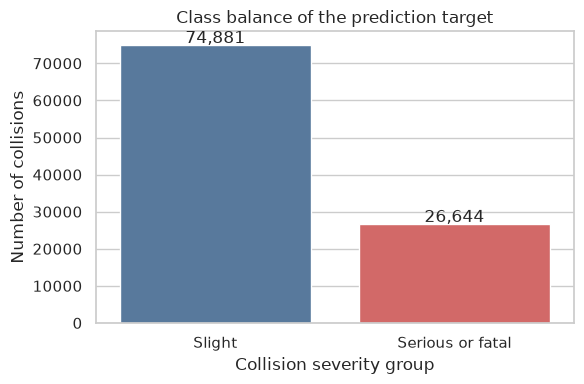

In [5]:
df["severity_label"] = df["collision_severity"].map({1: "Fatal", 2: "Serious", 3: "Slight"})
df["target_group"] = np.where(df["collision_severity"] <= 2, "Serious or fatal", "Slight")

severity_counts = df["severity_label"].value_counts().reindex(["Fatal", "Serious", "Slight"])
group_counts = df["target_group"].value_counts()
print(pd.DataFrame({"count": severity_counts, "share": (severity_counts / len(df)).round(4)}))
print()
print(pd.DataFrame({"count": group_counts, "share": (group_counts / len(df)).round(4)}))

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=group_counts.index, y=group_counts.values, hue=group_counts.index,
            palette=PALETTE, legend=False, ax=ax)
for i, v in enumerate(group_counts.values):
    ax.text(i, v + 600, f"{v:,}", ha="center")
ax.set_title("Class balance of the prediction target")
ax.set_xlabel("Collision severity group")
ax.set_ylabel("Number of collisions")
plt.tight_layout()
plt.savefig("figures/figure_1_class_balance.png", dpi=150)
plt.show()

**Interpretation.** Of the 101,525 collisions, 1,453 (1.4%) were fatal, 25,191 (24.8%) were serious and 74,881 (73.8%) were slight. Combining fatal and serious gives 26,644 collisions (26.2%) in the positive class. The classes are therefore imbalanced, and a model that always predicted *slight* would be right 73.8% of the time while detecting no serious or fatal collision at all. For that reason accuracy is not used as the main measure of success.

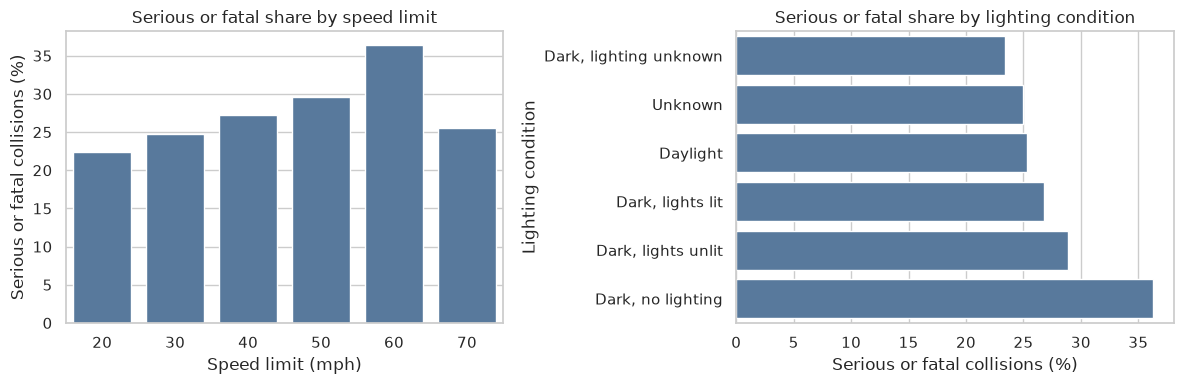

speed_limit
20    22.4
30    24.8
40    27.3
50    29.6
60    36.4
70    25.5

light
Dark, lighting unknown    23.4
Unknown                   25.0
Daylight                  25.3
Dark, lights lit          26.8
Dark, lights unlit        28.9
Dark, no lighting         36.3


In [6]:
# How the serious or fatal share varies with two scene characteristics
LIGHT = {1: "Daylight", 4: "Dark, lights lit", 5: "Dark, lights unlit", 6: "Dark, no lighting",
         7: "Dark, lighting unknown", -1: "Unknown"}
tmp = df.assign(
    light=df["light_conditions"].map(LIGHT),
    ksi=(df["collision_severity"] <= 2).astype(int),
)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
speed = tmp.groupby("speed_limit")["ksi"].mean() * 100
sns.barplot(x=speed.index.astype(str), y=speed.values, color="#4C78A8", ax=axes[0])
axes[0].set_title("Serious or fatal share by speed limit")
axes[0].set_xlabel("Speed limit (mph)")
axes[0].set_ylabel("Serious or fatal collisions (%)")
light = tmp.groupby("light")["ksi"].mean().sort_values() * 100
sns.barplot(x=light.values, y=light.index, color="#4C78A8", ax=axes[1])
axes[1].set_title("Serious or fatal share by lighting condition")
axes[1].set_xlabel("Serious or fatal collisions (%)")
axes[1].set_ylabel("Lighting condition")
plt.tight_layout()
plt.savefig("figures/figure_2_severity_by_speed_and_light.png", dpi=150)
plt.show()
print(speed.round(1).to_string())
print()
print(light.round(1).to_string())

**Interpretation.** The share of serious or fatal collisions rises with the speed limit from 22.4% at 20 mph to 36.4% at 60 mph, then falls to 25.5% at 70 mph. The fall at 70 mph is not explained by this chart alone. Collisions in darkness with no street lighting are the most severe lighting group (36.3% serious or fatal, against 25.3% in daylight). These simple patterns are plausible, but the differences are modest, which suggests that no single scene characteristic will predict severity strongly.

## 3. Data Preparation and Preprocessing

**Feature selection.** I keep only fields that describe the scene and could in principle be known when a collision is recorded:

- road and junction: `road_type`, `first_road_class`, `speed_limit`, `junction_detail`, `junction_control`, `pedestrian_crossing`, `trunk_road_flag`, `urban_or_rural_area`
- conditions: `light_conditions`, `weather_conditions`, `road_surface_conditions`, `special_conditions_at_site`, `carriageway_hazards`
- context: `number_of_vehicles`, `day_of_week`, and the hour and month taken from `time` and `date`

**Features deliberately excluded.**

- *Target leakage:* `number_of_casualties`, `enhanced_severity_collision`, `collision_injury_based` and the two `collision_adjusted_severity` columns. These describe the outcome of the collision or are derived from the severity label, so using them would let the model see the answer.
- *Recorded after the event:* `did_police_officer_attend_scene_of_accident`.
- *Identifiers:* `collision_index` and `collision_ref_no`.
- *Location fields:* coordinates, police force, local authority and LSOA. Location would let the model learn where past serious collisions were reported, which risks reflecting differences in policing and reporting between areas and not the road conditions I am interested in.

In [7]:
CATEGORICAL = [
    "road_type", "first_road_class", "junction_detail", "junction_control", "pedestrian_crossing",
    "trunk_road_flag", "urban_or_rural_area", "light_conditions", "weather_conditions",
    "road_surface_conditions", "special_conditions_at_site", "carriageway_hazards", "day_of_week",
]
NUMERIC = ["speed_limit", "number_of_vehicles"]
CYCLIC = ["hour", "month"]


def add_time_features(frame):
    """Return a copy with hour (0-23) and month (1-12) parsed from the DfT time and date columns."""
    out = frame.copy()
    out["hour"] = pd.to_datetime(out["time"], format="%H:%M").dt.hour
    out["month"] = pd.to_datetime(out["date"], format="%d/%m/%Y").dt.month
    return out


def standardise_unknown(frame):
    """Map the DfT unknown codes (-1, 9, 99) to a single code (-1) in every categorical column."""
    out = frame.copy()
    for col in CATEGORICAL:
        out[col] = out[col].where(~out[col].isin(UNKNOWN_CODES), -1)
    out["number_of_vehicles"] = out["number_of_vehicles"].clip(upper=6)
    return out


model_df = standardise_unknown(add_time_features(df))
X = model_df[CATEGORICAL + NUMERIC + CYCLIC]
y = (df["collision_severity"] <= 2).astype(int)   # 1 = serious or fatal

print("Feature matrix:", X.shape, "  Positive class share:", round(y.mean(), 4))
X.head()

Feature matrix: (101525, 17)   Positive class share: 0.2624


,road_type,first_road_class,junction_detail,junction_control,pedestrian_crossing,trunk_road_flag,urban_or_rural_area,light_conditions,weather_conditions,road_surface_conditions,special_conditions_at_site,carriageway_hazards,day_of_week,speed_limit,number_of_vehicles,hour,month
0,6,4,0,-1,13,2,1,1,1,1,-1,0,3,30,1,15,2
1,6,5,0,-1,0,2,1,1,1,1,-1,0,4,30,2,9,5
2,6,6,13,2,15,2,2,4,1,2,-1,0,5,30,2,18,11
3,6,5,0,-1,0,2,2,1,1,1,-1,0,5,40,2,16,5
4,3,1,0,-1,-1,1,2,4,1,2,-1,0,2,70,6,7,12


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
print(f"Training rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print(f"Serious or fatal share, train: {y_train.mean():.4f}   test: {y_test.mean():.4f}")

Training rows: 81,220   Test rows: 20,305
Serious or fatal share, train: 0.2624   test: 0.2624


**Preprocessing pipeline.** The same transformations are applied to every model through a single `ColumnTransformer`, and they are fitted on training data only so that nothing from the test set leaks into training.

- *Categorical fields* (code numbers that are labels) are one-hot encoded. Categories with fewer than 50 training rows are grouped together so that very rare codes do not create unstable columns.
- *Speed limit and number of vehicles* are standardised. This matters for logistic regression, which is sensitive to scale, and does no harm to tree models. Number of vehicles is capped at 6 because values above that are very rare.
- *Hour and month* are cyclical, so hour 23 is next to hour 0 and December is next to January. I encode each as a sine and cosine pair so that this closeness is preserved.
- Missing information is already coded as a single *unknown* category, so no rows are dropped and no values are invented.

In [9]:
def cyclic_encode(frame):
    """Sine and cosine encoding for hour (period 24) and month (period 12)."""
    hour = frame["hour"].to_numpy()
    month = frame["month"].to_numpy()
    return np.column_stack([
        np.sin(2 * np.pi * hour / 24), np.cos(2 * np.pi * hour / 24),
        np.sin(2 * np.pi * month / 12), np.cos(2 * np.pi * month / 12),
    ])


def make_preprocessor():
    """Build the shared preprocessing step."""
    return ColumnTransformer([
        ("categorical", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50, sparse_output=False), CATEGORICAL),
        ("numeric", StandardScaler(), NUMERIC),
        ("cyclic", FunctionTransformer(cyclic_encode), CYCLIC),
    ])


preprocessor = make_preprocessor().fit(X_train)
n_features = preprocessor.transform(X_train.head(5)).shape[1]
print("Number of model input columns after preprocessing:", n_features)

Number of model input columns after preprocessing: 91


## 4. Model Selection and Training

**Models compared.** Four models are trained on identical data so that their performance can be compared fairly.

1. *Dummy classifier* (always predicts the most frequent class). This is the baseline that any useful model must beat.
2. *Logistic regression*, an interpretable linear model that is a standard first choice for binary classification.
3. *Random forest*, an ensemble of decision trees that can capture interactions between conditions (for example speed limit combined with darkness) without them being specified in advance.
4. *Histogram gradient boosting*, a boosted tree ensemble that often performs strongly on tabular data.

**Handling class imbalance.** Only about a quarter of collisions are serious or fatal. The linear and random forest models use balanced class weights so that the minority class is not ignored. I do not resample the data, which keeps the test set a realistic reflection of how collisions are actually distributed.

**Model selection.** Models are compared with stratified 5-fold cross-validation on the training set only. The test set is not used until the final evaluation.

In [10]:
candidates = {
    "Dummy baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "Random forest": RandomForestClassifier(
        n_estimators=200, min_samples_leaf=30, class_weight="balanced_subsample",
        n_jobs=-1, random_state=SEED),
    "Gradient boosting": HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=250, max_leaf_nodes=15, l2_regularization=1.0,
        class_weight="balanced", random_state=SEED),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {"f1": "f1", "precision": make_scorer(precision_score, zero_division=0), "recall": "recall",
           "roc_auc": "roc_auc", "average_precision": "average_precision"}

rows = []
for name, estimator in candidates.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", estimator)])
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    rows.append({"Model": name, **{k: res[f"test_{k}"].mean() for k in scoring},
                 "roc_auc_sd": res["test_roc_auc"].std()})
cv_results = pd.DataFrame(rows).set_index("Model").round(4)
cv_results

,f1,precision,recall,roc_auc,average_precision,roc_auc_sd
Model,,,,,,
Dummy baseline,0.0000,0.0000,0.0000,0.5000,0.2624,0.0000
Logistic regression,0.4231,0.3251,0.6054,0.6167,0.3581,0.0019
Random forest,0.4308,0.3502,0.5594,0.6346,0.3761,0.0020
Gradient boosting,0.4331,0.3435,0.5860,0.6337,0.3742,0.0020


**Interpretation.** Every model beats the dummy baseline, whose average precision (0.262) simply equals the share of serious or fatal collisions. The three real models are close to each other. Cross-validated average precision is 0.358 for logistic regression, 0.376 for the random forest and 0.374 for gradient boosting, and ROC AUC is between 0.617 and 0.635. Fold-to-fold variation in ROC AUC is small (a standard deviation of about 0.002), so the ranking between the models is stable, but the gap between the random forest and gradient boosting is too small to say that either is clearly better. The random forest is selected because it has the highest average precision.

In [11]:
# Choose the model with the best cross-validated average precision (area under the precision-recall curve)
best_name = cv_results.drop(index="Dummy baseline")["average_precision"].idxmax()
print("Best model on cross-validated average precision:", best_name)

Best model on cross-validated average precision: Random forest


**Light hyperparameter tuning.** The selected model's main settings are tuned with a small grid search, again using only the training set and cross-validation. The grids are deliberately small, since the goal is a well-behaved model and not the last fraction of a percentage point.

In [12]:
param_grids = {
    "Logistic regression": {"model__C": [0.01, 0.1, 1.0]},
    "Random forest": {"model__min_samples_leaf": [10, 30, 60], "model__max_depth": [None, 20]},
    "Gradient boosting": {"model__learning_rate": [0.05, 0.1], "model__max_leaf_nodes": [8, 15, 31]},
}
base_pipe = Pipeline([("prep", make_preprocessor()), ("model", candidates[best_name])])
search = GridSearchCV(base_pipe, param_grids[best_name], scoring="average_precision",
                      cv=cv, n_jobs=1, refit=True)
search.fit(X_train, y_train)
print("Best parameters:", search.best_params_)
print("Cross-validated average precision of tuned model:", round(search.best_score_, 4))
final_model = search.best_estimator_

Best parameters: {'model__max_depth': 20, 'model__min_samples_leaf': 30}
Cross-validated average precision of tuned model: 0.3766


**Interpretation.** The grid search chose a maximum depth of 20 and a minimum of 30 samples per leaf. The cross-validated average precision rose only from 0.3761 to 0.3766, so the model was already close to the best that these inputs allow and tuning added almost nothing.

Threshold chosen on training data: 0.44  (training F1 at this threshold: 0.4448)


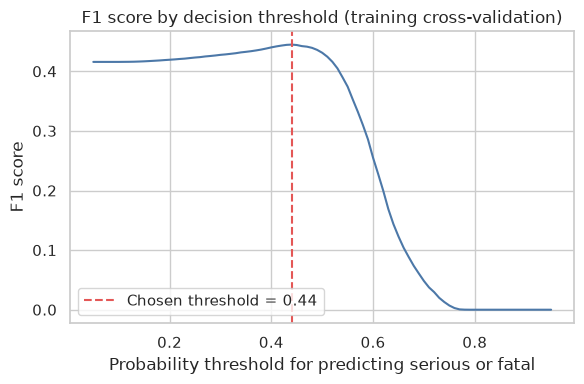

In [13]:
# Decision threshold. Out-of-fold predictions on the TRAINING data pick the threshold that maximises F1,
# so the test set stays untouched.
oof_scores = cross_val_predict(final_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=1)[:, 1]
thresholds = np.linspace(0.05, 0.95, 91)
f1_by_threshold = [f1_score(y_train, oof_scores >= t) for t in thresholds]
best_threshold = float(thresholds[int(np.argmax(f1_by_threshold))])
print(f"Threshold chosen on training data: {best_threshold:.2f}  (training F1 at this threshold: {max(f1_by_threshold):.4f})")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(thresholds, f1_by_threshold, color="#4C78A8")
ax.axvline(best_threshold, color="#E45756", linestyle="--", label=f"Chosen threshold = {best_threshold:.2f}")
ax.set_title("F1 score by decision threshold (training cross-validation)")
ax.set_xlabel("Probability threshold for predicting serious or fatal")
ax.set_ylabel("F1 score")
ax.legend()
plt.tight_layout()
plt.savefig("figures/figure_3_threshold_selection.png", dpi=150)
plt.show()

**Interpretation.** A model that outputs probabilities needs a cut-off for deciding which collisions to label serious or fatal. The cut-off that maximised F1 on the training cross-validation was 0.44, which gave a training F1 of 0.445. It is below 0.5 because the serious or fatal class is the minority and F1 rewards finding more of it. A different cut-off would trade precision against recall, and the right choice depends on the cost of missing a serious collision compared with the cost of a false alarm.

## 5. Model Evaluation

The tuned model is now evaluated once on the held-out test set. I report precision, recall, F1, ROC AUC and average precision. Accuracy is shown only for comparison, because a model that always predicts *slight* would already be correct about three times in four.

In [14]:
test_scores = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_scores >= best_threshold).astype(int)
baseline_pred = np.zeros_like(y_test)

metrics = pd.DataFrame({
    "Always predict slight": [accuracy_score(y_test, baseline_pred), 0.0, 0.0, 0.0, 0.5, y_test.mean()],
    f"Tuned {best_name}": [accuracy_score(y_test, test_pred), precision_score(y_test, test_pred),
                           recall_score(y_test, test_pred), f1_score(y_test, test_pred),
                           roc_auc_score(y_test, test_scores), average_precision_score(y_test, test_scores)],
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC AUC", "Average precision"]).round(4)
display(metrics)
print(classification_report(y_test, test_pred, target_names=["Slight", "Serious or fatal"], digits=3))

,Always predict slight,Tuned Random forest
Accuracy,0.7376,0.4741
Precision,0.0000,0.3106
Recall,0.0000,0.8230
F1,0.0000,0.4510
ROC AUC,0.5000,0.6397
Average precision,0.2624,0.3712


                  precision    recall  f1-score   support

          Slight      0.848     0.350     0.495     14976
Serious or fatal      0.311     0.823     0.451      5329

        accuracy                          0.474     20305
       macro avg      0.579     0.587     0.473     20305
    weighted avg      0.707     0.474     0.484     20305



**Interpretation.** On the held-out test set the model reaches an F1 score of 0.451, recall of 0.823, precision of 0.311, ROC AUC of 0.640 and average precision of 0.371 (against 0.262 for a no-skill model). Recall of 0.823 means the model identifies about 82 of every 100 serious or fatal collisions. Precision of 0.311 means that only about 31 of every 100 collisions it flags are truly serious or fatal. Accuracy is 0.474, which is lower than the 0.738 achieved by always predicting *slight*, because the chosen cut-off deliberately flags many slight collisions in order to catch serious ones (recall for the slight class is only 0.350). The test results are very close to the cross-validation results (average precision 0.371 against 0.377, ROC AUC 0.640 against 0.635), so there is no sign of overfitting. The model has real but limited predictive skill.

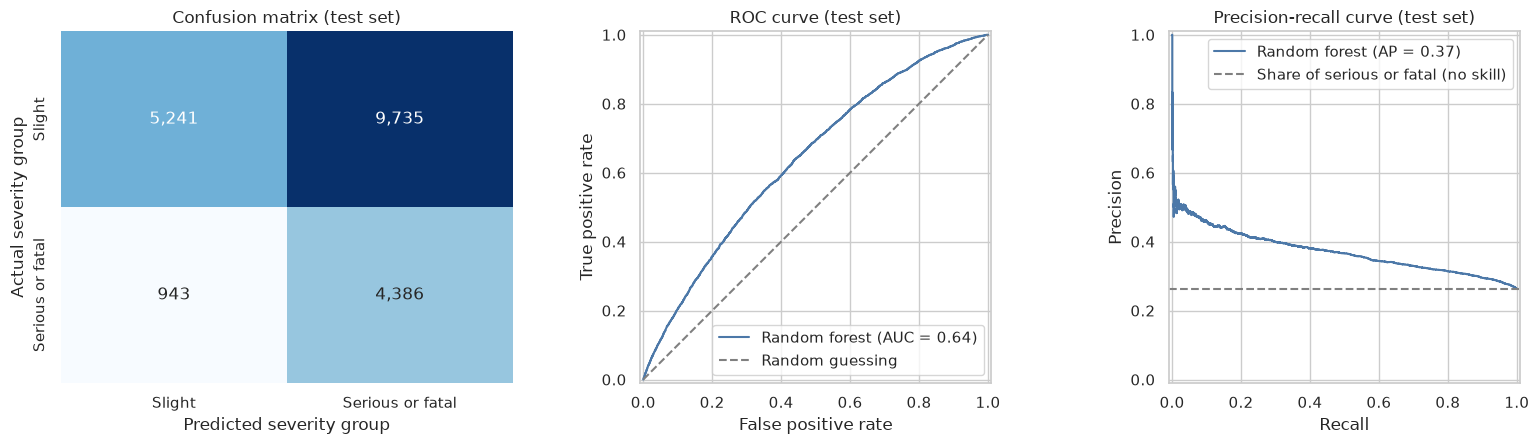

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
cm = confusion_matrix(y_test, test_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=axes[0],
            xticklabels=["Slight", "Serious or fatal"], yticklabels=["Slight", "Serious or fatal"])
axes[0].set_title("Confusion matrix (test set)")
axes[0].set_xlabel("Predicted severity group")
axes[0].set_ylabel("Actual severity group")
RocCurveDisplay.from_predictions(y_test, test_scores, ax=axes[1], curve_kwargs={"color": "#4C78A8"}, name=best_name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guessing")
axes[1].set_title("ROC curve (test set)")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].legend(loc="lower right")
PrecisionRecallDisplay.from_predictions(y_test, test_scores, ax=axes[2], curve_kwargs={"color": "#4C78A8"}, name=best_name)
axes[2].axhline(y_test.mean(), linestyle="--", color="grey", label="Share of serious or fatal (no skill)")
axes[2].set_title("Precision-recall curve (test set)")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend(loc="upper right")
plt.tight_layout()
plt.savefig("figures/figure_4_evaluation_curves.png", dpi=150)
plt.show()

**Interpretation.** The ROC and precision-recall curves lie above their chance reference lines, which confirms that the model ranks serious or fatal collisions higher than slight ones more often than chance would. They do not lie far above those lines, which matches a ROC AUC of 0.640. The confusion matrix shows the cost of the chosen cut-off: many slight collisions are predicted to be serious or fatal.

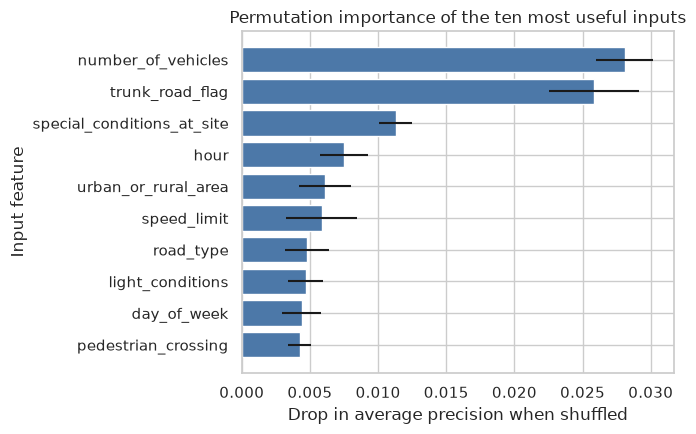

number_of_vehicles            0.0281
trunk_road_flag               0.0258
special_conditions_at_site    0.0113
hour                          0.0075
urban_or_rural_area           0.0061
speed_limit                   0.0059
road_type                     0.0048
light_conditions              0.0047
day_of_week                   0.0044
pedestrian_crossing           0.0043
dtype: float64

In [16]:
# Which inputs matter most? Permutation importance on a test sample: the drop in average precision when
# one input is shuffled. It is computed on original (not one-hot) inputs, so each bar is one scene feature.
rng = np.random.RandomState(SEED)
idx = rng.choice(len(X_test), size=8000, replace=False)
perm = permutation_importance(final_model, X_test.iloc[idx], y_test.iloc[idx], scoring="average_precision",
                              n_repeats=5, random_state=SEED, n_jobs=1)
importance = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
top = importance.head(10).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top.index, top.values, xerr=pd.Series(perm.importances_std, index=X_test.columns)[top.index].values,
        color="#4C78A8")
ax.set_title("Permutation importance of the ten most useful inputs")
ax.set_xlabel("Drop in average precision when shuffled")
ax.set_ylabel("Input feature")
plt.tight_layout()
plt.savefig("figures/figure_5_permutation_importance.png", dpi=150)
plt.show()
importance.round(4).head(10)

In [17]:
# What lies behind the two most important inputs? Serious or fatal share (%) and number of collisions by value.
ksi = (df["collision_severity"] <= 2)
for col in ["number_of_vehicles", "trunk_road_flag"]:
    table = ksi.groupby(model_df[col]).agg(["mean", "size"])
    table["mean"] = (table["mean"] * 100).round(1)
    print(col); print(table.head(7).rename(columns={"mean": "serious_or_fatal_pct", "size": "collisions"}).to_string()); print()
unknown_trunk = df[model_df["trunk_road_flag"] == -1]
print("Collisions with unknown trunk road flag:", len(unknown_trunk))
print("Of which in police force code 99:", int((unknown_trunk["police_force"] == 99).sum()))

number_of_vehicles
                    serious_or_fatal_pct  collisions
number_of_vehicles                                  
1                                   32.8       30841
2                                   22.7       61869
3                                   27.3        6876
4                                   28.8        1331
5                                   30.4         405
6                                   34.0         203

trunk_road_flag
                 serious_or_fatal_pct  collisions
trunk_road_flag                                  
-1                               40.3        7108
 1                               24.4        6447
 2                               25.2       87970

Collisions with unknown trunk road flag: 7108
Of which in police force code 99: 4104


**Interpretation.** The inputs whose shuffling reduces average precision the most are the number of vehicles (0.028) and the trunk road flag (0.026), followed by special conditions at the site, hour of day, urban or rural area and speed limit. Single-vehicle collisions are more often serious or fatal (32.8%) than two-vehicle collisions (22.7%). The trunk road flag needs caution. Collisions with an *unknown* trunk road flag are serious or fatal 40.3% of the time, against 24.4% for trunk roads and 25.2% for other roads, and 4,104 of the 7,108 unknown cases come from a single police force code (99). The model is therefore partly using how a collision was recorded and not only what happened at the scene. This is a reason to treat the feature importances as a description of the model and the data, not as proof of what causes severe collisions.

**Checking for uneven performance across groups.** A model can perform well on average and still behave differently for some kinds of collision. I compare performance for urban and rural collisions, and across speed limit bands, as a check for one source of bias in the results.

In [18]:
def group_metrics(mask_series, label):
    """Test-set metrics for each value of a grouping variable."""
    out = []
    for value, idx_group in mask_series.groupby(mask_series).groups.items():
        pos = y_test.loc[idx_group]
        pred = pd.Series(test_pred, index=y_test.index).loc[idx_group]
        score = pd.Series(test_scores, index=y_test.index).loc[idx_group]
        out.append({label: value, "n": len(pos), "serious_or_fatal_share": pos.mean(),
                    "precision": precision_score(pos, pred, zero_division=0),
                    "recall": recall_score(pos, pred, zero_division=0),
                    "f1": f1_score(pos, pred, zero_division=0),
                    "roc_auc": roc_auc_score(pos, score) if pos.nunique() > 1 else np.nan})
    return pd.DataFrame(out).set_index(label).round(3)


area = X_test["urban_or_rural_area"].map({1: "Urban", 2: "Rural", 3: "Unallocated"})
speed_band = pd.cut(X_test["speed_limit"], [0, 30, 50, 100], labels=["20 to 30 mph", "40 to 50 mph", "60 to 70 mph"])
display(group_metrics(area[area != "Unallocated"], "Area type"))
display(group_metrics(speed_band, "Speed limit band"))

,n,serious_or_fatal_share,precision,recall,f1,roc_auc
Area type,,,,,,
Rural,6869,0.314,0.339,0.906,0.493,0.623
Urban,13435,0.236,0.291,0.766,0.422,0.635


,n,serious_or_fatal_share,precision,recall,f1,roc_auc
Speed limit band,,,,,,
20 to 30 mph,13887,0.240,0.290,0.789,0.424,0.632
40 to 50 mph,2756,0.276,0.324,0.836,0.467,0.634
60 to 70 mph,3662,0.339,0.362,0.907,0.518,0.620


**Interpretation.** The model ranks collisions about equally well in every group (ROC AUC between 0.620 and 0.635), but its precision and recall differ because the groups differ in how common serious or fatal collisions are. In rural areas 31.4% of collisions are serious or fatal and recall is 0.906 with precision of 0.339, while in urban areas 23.6% are serious or fatal and recall is 0.766 with precision of 0.291. The same pattern holds across speed limit bands, with recall rising from 0.789 (20 to 30 mph) to 0.907 (60 to 70 mph). With one shared cut-off, the model is therefore more likely to miss a serious urban collision than a serious rural one, while a flagged urban or low-speed collision is less likely to be truly serious (lower precision). Group-specific cut-offs, or a different cost trade-off, would be needed before using such a model in practice.

## 6. Notebook Summary

I modelled whether a 2025 Great Britain road collision was serious or fatal rather than slight, using 101,525 collisions from the Department for Transport open data and 17 scene and time features, with location fields and outcome-related fields excluded. Logistic regression, a random forest and gradient boosting were compared with cross-validation, and a lightly tuned random forest was selected. On the held-out test set it achieved recall of 0.823, precision of 0.311, F1 of 0.451 and ROC AUC of 0.640, which is better than chance but only modest. The main limitation is that scene conditions carry limited information about severity, so the model flags many slight collisions (accuracy is 0.474, below the 0.738 of a model that always predicts slight). A second challenge is that some predictive signal comes from how data were recorded, for example the unknown trunk road flag, and performance differs between urban and rural settings under a single cut-off. The model is therefore suitable as an exploratory risk-ranking exercise and not as a decision tool.